<a href="https://colab.research.google.com/github/Matthew725234/Python-projects/blob/main/dijkstra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import heapq
# pesi sul grafo salvati in una matrice di interi >= 0

def dijkstra(A,start,end):   # start: nodo di partenza, end: nodo di arrivo

  m = len(A)
  prec = [None]*m     # setto i nodi precedenti a None e le distanze a infinito
  dist = [float('inf')]*m
  dist[start] = 0        # la distanza del nodo di partenza è 0
  pq = [(0,start)]    # priority queue

  while pq:    # continuo fino a che la lista pq non è vuote
    d_attuale, u = heapq.heappop(pq)  # prendo il primo elemento di pq
    if u == end:
      break

    if d_attuale > dist[u]:
      continue

    for v in range(m):    # aggiorno le distanze
      peso = A[u][v]
      if peso != 0:
        nuova_distanza = peso + dist[u]
        if nuova_distanza < dist[v]:
          dist[v] = nuova_distanza
          prec[v] = u
          heapq.heappush(pq, (nuova_distanza, v))

  percorso = []     # ricostruisco il percorso da star a end
  curr = end
  if dist[end] == float('inf'):  # caso in cui end sia irraggiungibile
    return float('inf'),[]

  while curr is not None:
    percorso.append(curr)
    curr = prec[curr]
  percorso.reverse()

  return dist[end], percorso


In [9]:
# test dell'algoritmo (solo numerico)

# Matrice di adiacenza 10x10
# I nodi vanno da 0 a 9
A = [
    [0, 5, 2, 0, 0, 0, 0, 0, 0, 0], # Nodo 0
    [0, 0, 0, 4, 2, 0, 0, 0, 0, 0], # Nodo 1
    [0, 8, 0, 0, 0, 7, 0, 0, 0, 0], # Nodo 2
    [0, 0, 0, 0, 0, 0, 6, 0, 0, 20],# Nodo 3
    [0, 0, 0, 1, 0, 3, 0, 8, 0, 0], # Nodo 4
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0], # Nodo 5
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 5], # Nodo 6
    [0, 0, 0, 0, 0, 0, 0, 0, 3, 0], # Nodo 7
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 2], # Nodo 8
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  # Nodo 9
]

start_node = 0
end_node = 9

costo_totale, percorso = dijkstra(A, start_node, end_node)

print(f"--- TEST DIJKSTRA ---")
print(f"Partenza: {start_node} -> Arrivo: {end_node}")
print(f"Percorso trovato: {percorso}")
print(f"Costo totale: {costo_totale}")

--- TEST DIJKSTRA ---
Partenza: 0 -> Arrivo: 9
Percorso trovato: [0, 2, 5, 7, 8, 9]
Costo totale: 15


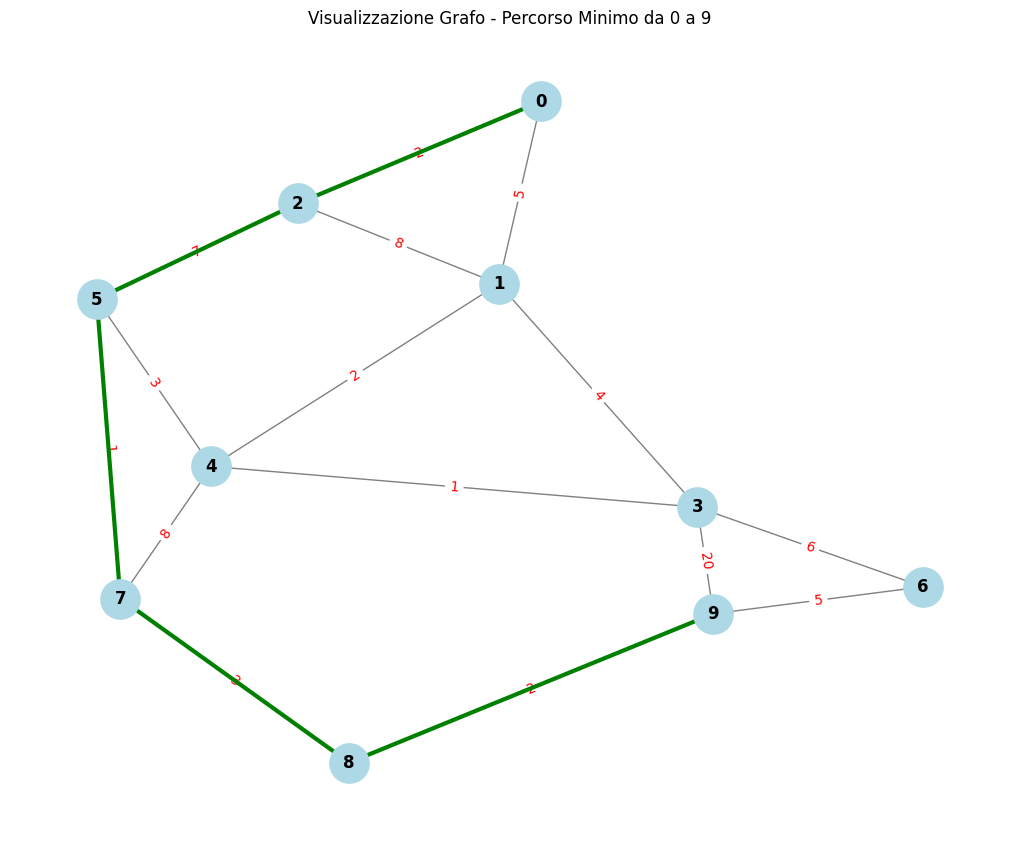

In [16]:
# visualizzazione grafica
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()

for i in range(len(A)):
  G.add_node(i)
for i in range(len(A)):
  for j in range(len(A)):
    if A[i][j] != 0:
      G.add_edge(i,j,weight = A[i][j])

# 1. Definiamo la posizione dei nodi (layout a molla)
pos = nx.spring_layout(G, seed=42)

# 2. Disegniamo i nodi e gli archi base
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=800, font_size=12, font_weight='bold', edge_color='gray')

# 3. Aggiungiamo le etichette dei pesi sugli archi
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

path_edges = list(zip(percorso, percorso[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='green', width=3)

plt.title(f"Visualizzazione Grafo - Percorso Minimo da {start_node} a {end_node}")

plt.show()